In [22]:
# Midterm Project: Mini Data Science Project
# Christian V. Buzarang and Ericka Fatima Reign R. Ligaray
# BSCS - 3 F2
# CS365: Applied AI
# October 14, 2026

# Data Selection:
# - Video Game Sales

# Data Analysis Techniques:
# - K-Means Clustering, Classification, Linear Regression

# Data Preparation:
# - Clean the data, handle missing values, and prepare it for the chosen analysis technique.
    
# Analysis and Insights:
# - Use the selected technique to analyze the dataset. Dive deep into the insights and patterns that emerge from your analysis.
    
# Presentation Preparation:
# - Prepare a presentation to showcase your findings to the class. Create visualizations on both the descriptive statistics 
#   and the results of your analysis and provide clear explanations for the insights you've gathered. Take note of the 
#   suggestions and recommendations I've outlined regarding visualizing data from your midterm project.
    
# Grading Criteria:
    # Analysis Technique (30%)
    # - Alignment of the chosen analysis technique with the dataset and research question.

    # Depth and Quality of Insights (30%)
    # - Clear interpretation of results with meaningful insights.
    # - Exploration of patterns, trends, or anomalies in the data.
    
    # Data Visualization (15%)
    # - Appropriate use of charts and graphs for the given data.

    # Creativity and Novelty (15%)
    # - Presentation of unique or surprising findings.
    # - Exploration of creative approaches to the problem or dataset.
    
    # Presentation Quality (10%)
    # - Clarity and coherence of the presentation.
    # - Use of effective visualizations to explain findings.
    # - Engagement and conciseness in delivering the recorded presentation.

In [23]:

# Data Manipulation & Numerics
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# K-Means Clustering & Dim Reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Classification Models & Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# Linear Regression Models & Metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# DATA LOAD AND CLEANING

# Load the dataset
df = pd.read_csv("vgsales.csv")

# Quick look at structure and missing values
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# Drop rows with missing critical metadata (Year, Publisher)
df_clean = df.dropna(subset=["Year", "Publisher"]).copy()
df_clean["Year"] = df_clean["Year"].astype(int)

# Filter out non-positive sales if performing log transforms
df_clean = df_clean[df_clean["Global_Sales"] > 0].reset_index(drop=True)
print(f"\nCleaned dataset size: {df_clean.shape[0]} rows")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None

Missing values:
 Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Cleaned datas

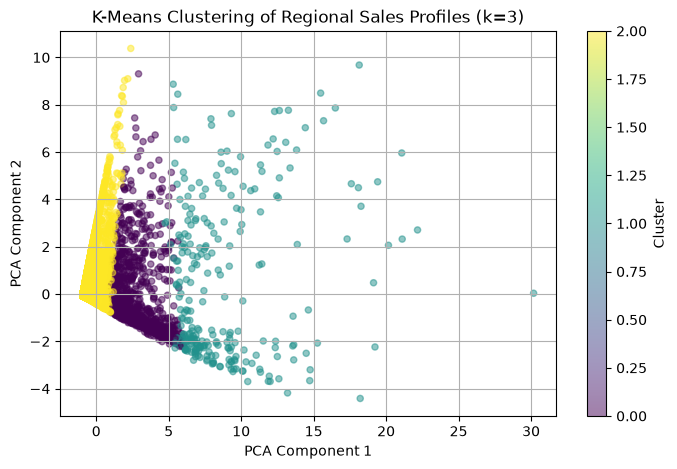

         NA_Sales  EU_Sales  JP_Sales  Other_Sales
Cluster                                           
0        0.886296  0.504864  0.118569     0.157376
1        3.866952  2.672677  1.136245     0.921004
2        0.100298  0.043816  0.052227     0.014743


In [25]:
# K-MEANS CLUSTERING DATA ANALYSIS

# Feature selection: regional sales proportions / volumes
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
X_sales = df_clean[sales_cols].values

# Log transform and scale
X_log = np.log1p(X_sales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Fit K-Means (e.g., k=3 for Regional Profiles)
k = 3
kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualize using PCA (2D projection)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=df_clean["Cluster"], cmap="viridis", alpha=0.5, s=20
)
plt.title(f"K-Means Clustering of Regional Sales Profiles (k={k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

# Examine cluster characteristics
print(df_clean.groupby("Cluster")[sales_cols].mean())

In [26]:
# CLASSIFICATION DATA ANALYSIS

# Define binary target: Hit (>= 1.0M) vs Not Hit (< 1.0M)
df_clean["Is_Hit"] = (df_clean["Global_Sales"] >= 1.0).astype(int)

# Select predictors
X_clf = df_clean[["Genre", "Platform", "Year"]]
y_clf = df_clean["Is_Hit"]

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Preprocessing pipeline (One-Hot encode categorical features)
cat_features = ["Genre", "Platform"]
num_features = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
        ("num", StandardScaler(), num_features),
    ]
)

# Train Random Forest Classifier
clf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100, max_depth=10, class_weight="balanced", random_state=42
            ),
        ),
    ]
)

clf_pipeline.fit(X_train_c, y_train_c)
y_pred_c = clf_pipeline.predict(X_test_c)

print(
    "Classification Report (Hit Prediction):\n",
    classification_report(y_test_c, y_pred_c),
)

Classification Report (Hit Prediction):
               precision    recall  f1-score   support

           0       0.94      0.62      0.75      2847
           1       0.22      0.72      0.33       412

    accuracy                           0.63      3259
   macro avg       0.58      0.67      0.54      3259
weighted avg       0.85      0.63      0.69      3259



In [27]:
# LINEAR REGRESSION DATA ANALYSIS

# Features and target (predict Global Sales using NA_Sales and Year)
X_reg = df_clean[["NA_Sales", "Genre", "Platform", "Year"]]
y_reg = df_clean["Global_Sales"]

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Regression Pipeline
reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["Genre", "Platform"],
        ),
        ("num", StandardScaler(), ["NA_Sales", "Year"]),
    ]
)

reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", Ridge(alpha=1.0)),
    ]
)

reg_pipeline.fit(X_train_r, y_train_r)
y_pred_r = reg_pipeline.predict(X_test_r)

# Evaluation Metrics
print(f"R² Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")

R² Score: 0.9233
Mean Absolute Error: 0.2036
Root Mean Squared Error: 0.5730
